In [11]:
%load_ext autoreload
%autoreload 2

%matplotlib inline

import numpy as np

import os
from pathlib import Path
import sys

# 1. Move the Notebook's "Current Working Directory" to the Root
# This ensures that 'data/raw' and 'logs/' are found correctly
if Path.cwd().name == "notebooks":
    os.chdir("..")

# 2. Add the Root to the Path so we can import everything
project_root = str(Path.cwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Current Working Directory: {os.getcwd()}")
print("Project Root injected into path.")




The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Current Working Directory: c:\Users\reymo\quant-portfolio
Project Root injected into path.


In [13]:
# 3. Import
import run_analytics
# 1. Re-run the pipeline
# Because we changed the directory to the Root, 'data/raw' is now visible!
res = run_analytics.run_analytics()

if res is not None:
    df_returns, optimizer, delta = res
    print("✅ SUCCESS: Data loaded and variables unpacked.")
else:
    # If this still fails, your return statement in run_analytics.py might not be saved
    print(
        "❌ FAILED: Still returning None. Verify the 'return' line is in your .py file."
    )

# 2. Calculate Risk Decomposition
target_daily = 0.0005
weights_dict = optimizer.get_optimal_weights(target_daily, delta=delta)
df_risk = optimizer.calculate_risk_decomposition(weights_dict, delta)

# Audit Concentration
df_risk["Risk_Concentration_Ratio"] = (
    df_risk["Percent_Contribution"] / df_risk["Weight"]
)
print(f"Primary Risk Driver: {df_risk['Percent_Contribution'].idxmax()}")

2026-02-03 16:13:16 - root - INFO - Found 20 tickers: ['AAPL', 'AIR.PA', 'AMZN', 'BNP.PA', 'DG.PA', 'GOOGL', 'JNJ', 'JPM', 'KO', 'MC.PA', 'MSFT', 'NVDA', 'OR.PA', 'PG', 'RMS.PA', 'SAN.PA', 'SU.PA', 'TSLA', 'TTE.PA', 'XOM']
2026-02-03 16:13:16 - root - INFO - Optimization Matrix Ready: (1033, 20)
2026-02-03 16:13:16 - root - INFO - Optimal Delta: 0.02
2026-02-03 16:13:16 - root - INFO - KKT Verification - Risk/Mu Ratio: 0.239317
2026-02-03 16:13:16 - root - INFO - Condition Number (Raw): 86.84
2026-02-03 16:13:16 - root - INFO - Condition Number (Shrunk): 70.15
2026-02-03 16:13:16 - root - INFO - Expected Annual Volatility: 33.00%



Ticker     | Raw Weights (%) | Shrunk/Tangency (%)
--------------------------------------------------
AAPL       | 0.00%           | 0.00%          
AIR.PA     | 0.00%           | 0.00%          
AMZN       | 0.00%           | 0.00%          
BNP.PA     | 0.00%           | 0.00%          
DG.PA      | 0.00%           | 0.00%          
GOOGL      | 0.00%           | 0.00%          
JNJ        | 0.00%           | 0.00%          
JPM        | 0.00%           | 0.00%          
KO         | 0.00%           | 0.00%          
MC.PA      | 0.00%           | 0.00%          
MSFT       | 0.00%           | 0.00%          
NVDA       | 30.21%          | 30.19%         
OR.PA      | 0.00%           | 0.00%          
PG         | 0.00%           | 0.00%          
RMS.PA     | 42.82%          | 41.98%         
SAN.PA     | 0.00%           | 0.00%          
SU.PA      | 0.00%           | 0.00%          
TSLA       | 20.18%          | 20.31%         
TTE.PA     | 0.79%           | 0.00%          
XOM 

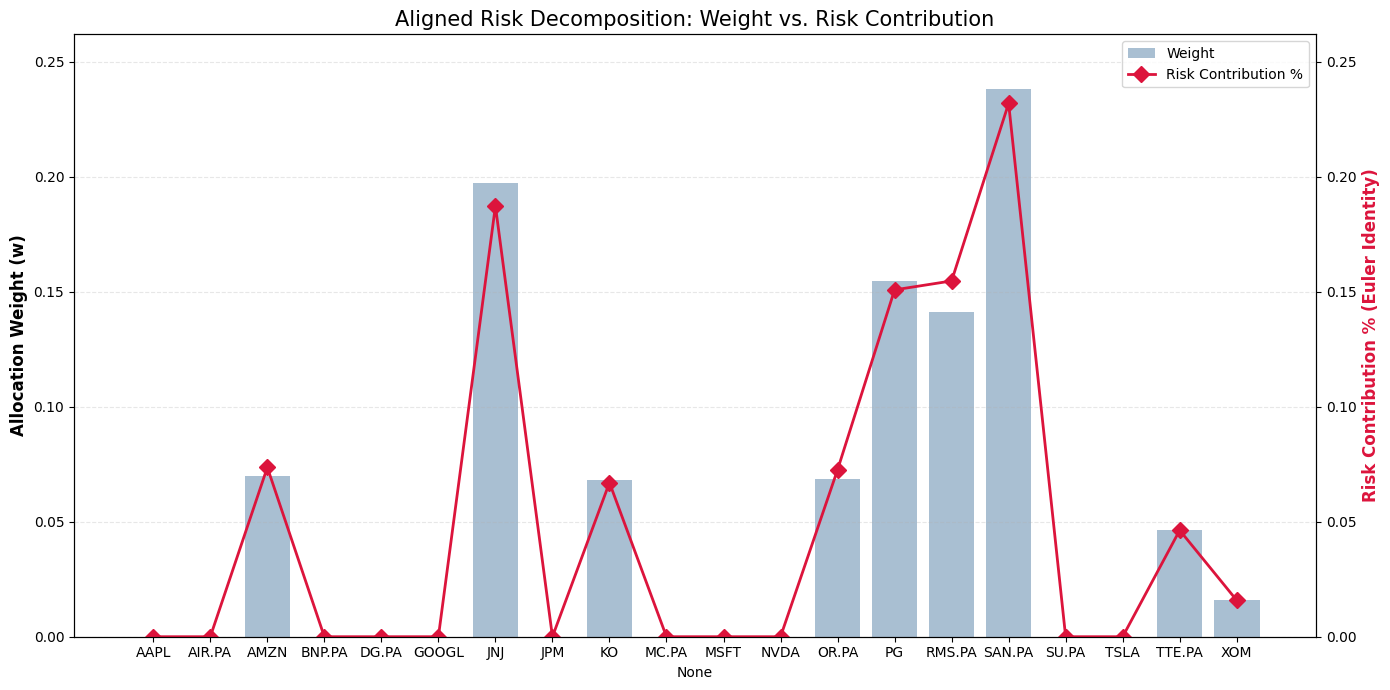

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Calculate the shared upper bound for the Y-axis
# We take the max of both Weight and Risk Contribution to ensure nothing is cut off
y_max = max(df_risk["Weight"].max(), df_risk["Percent_Contribution"].max()) * 1.1

fig, ax1 = plt.subplots(figsize=(14, 7))

# 2. Plot Weights (Capital)
sns.barplot(
    x=df_risk.index,
    y=df_risk["Weight"],
    ax=ax1,
    color="steelblue",
    alpha=0.5,
    label="Weight",
)
ax1.set_ylabel("Allocation Weight (w)", fontsize=12, fontweight="bold")
ax1.set_ylim(0, y_max)  # <--- Force scale

# 3. Create Secondary Axis for Risk Contribution
ax2 = ax1.twinx()
ax2.plot(
    df_risk.index,
    df_risk["Percent_Contribution"],
    color="crimson",
    marker="D",
    markersize=8,
    linewidth=2,
    label="Risk Contribution %",
)
ax2.set_ylabel(
    "Risk Contribution % (Euler Identity)",
    fontsize=12,
    fontweight="bold",
    color="crimson",
)
ax2.set_ylim(0, y_max)  # <--- Force identical scale

# 4. Cleanup and Legend
plt.title("Aligned Risk Decomposition: Weight vs. Risk Contribution", fontsize=15)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Synchronizing grid lines (optional but cleaner)
ax2.grid(False)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="upper right")

plt.tight_layout()
plt.show()

In [9]:
# Calculate Weighted Average of individual volatilities
# sigma_i is the square root of the diagonal of our covariance matrix.
# Align explicitly to optimizer.tickers so we never rely on positional order.
tickers = optimizer.tickers
w_aligned = df_risk["Weight"].reindex(tickers)
if w_aligned.isna().any():
    raise ValueError("df_risk missing weights for some optimizer tickers")
sigma_shrunk = optimizer._apply_ledoit_wolf_shrinkage(delta)
individual_vols_arr = np.sqrt(np.diag(sigma_shrunk))  # same order as optimizer.tickers
weighted_vols = (w_aligned.values * individual_vols_arr).sum()

# Calculate Portfolio Volatility (from our decomposition or matrix math)
portfolio_vol = np.sqrt(
    np.dot(
        df_risk["Weight"].T,
        np.dot(optimizer._apply_ledoit_wolf_shrinkage(delta), df_risk["Weight"]),
    )
)

dr = weighted_vols / portfolio_vol

print(f"Diversification Ratio: {dr:.4f}")
print(
    "Interpretation: A DR > 1 means your portfolio is less volatile than the simple average of its assets."
)

Diversification Ratio: 1.6538
Interpretation: A DR > 1 means your portfolio is less volatile than the simple average of its assets.
